# Signature Recognition & Forgery Detection

## 1. Project Objective

The objective of this project is to develop a deep learning-based
signature verification system that can distinguish between genuine
and forged handwritten signatures.

The project will explore:
- Convolutional Neural Networks (CNN)
- Recurrent Neural Networks (RNN/LSTM)
- Artificial Neural Networks (ANN)
- Feature extraction and fusion
- Model evaluation
- Signature verification and forgery detection

## 2. Import Libraries

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image      #PIL = python imaging library

print("Libraries imported successfully!")

Libraries imported successfully!


In [9]:
import sys

print("Python version:", sys.version)
print("Python executable:", sys.executable)

Python version: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]
Python executable: C:\ProgramData\sakshi\anaconda3\python.exe


## 3. Load Dataset / Dataset Structure
We first inspect one real file → understand its structure → then write the correct loader.

In [10]:
#We first inspect one real file → understand its structure → then write the correct loader.
import os

dataset_path = r"C:\Users\saksh\Downloads\Task2\Task2"

print(os.path.exists(dataset_path))

True


In [11]:
files = os.listdir(dataset_path)

print("Number of files:", len(files))
print("\nFirst 10 files:")

for file in files[:10]:
    print(file)

Number of files: 1600

First 10 files:
U10S1.TXT
U10S10.TXT
U10S11.TXT
U10S12.TXT
U10S13.TXT
U10S14.TXT
U10S15.TXT
U10S16.TXT
U10S17.TXT
U10S18.TXT


In [12]:
first_file = os.path.join(dataset_path, files[0])

print("File:", first_file)

with open(first_file, "r") as f:
    for i in range(10):
        print(f.readline().strip())

File: C:\Users\saksh\Downloads\Task2\Task2\U10S1.TXT
142
3236 5028 17638839 0 1260 400 351
3428 4998 17638849 1 1260 400 382
3541 5056 17638859 1 1260 400 394
3665 5135 17638869 1 1310 400 397
3945 5229 17638879 1 1370 390 405
4243 5429 17638889 1 1420 380 392
4553 5595 17638899 1 1470 370 376
4855 5738 17638909 1 1460 390 363
5075 5900 17638919 1 1450 390 359


Each row has 7 values. This is excellent for our RNN/LSTM because each signature is a sequence of points.

## 4. Inspecting an Online Signature

Each signature is represented as a sequence of pen movement
measurements. The measurements contain spatial and dynamic
information such as X/Y position, timestamp, pen status,
azimuth, altitude, and pressure.

In [13]:
import os
import pandas as pd

file_path = os.path.join(dataset_path, "U10S1.TXT")

# Read the first line: number of data points
with open(file_path, "r") as f:
    num_points = int(f.readline().strip())

print("Number of data points:", num_points)

Number of data points: 142


In [14]:
columns = [
    "x","y","timestamp","pen_status","azimuth","altitude","pressure"
]

signature = pd.read_csv(
    file_path,sep=r"\s+",skiprows=1,header=None,names=columns
)

signature.head()

,x,y,timestamp,pen_status,azimuth,altitude,pressure
0,3236,5028,17638839,0,1260,400,351
1,3428,4998,17638849,1,1260,400,382
2,3541,5056,17638859,1,1260,400,394
3,3665,5135,17638869,1,1310,400,397
4,3945,5229,17638879,1,1370,390,405


In [15]:
print("Shape:", signature.shape)

Shape: (142, 7)


THIS is exactly the type of structure our LSTM can learn from.

## 5. Visualizing the Signature Trajectory

A signature can be represented as a sequence of pen movements.
The X and Y coordinates allow us to reconstruct the path followed
by the pen while writing the signature.

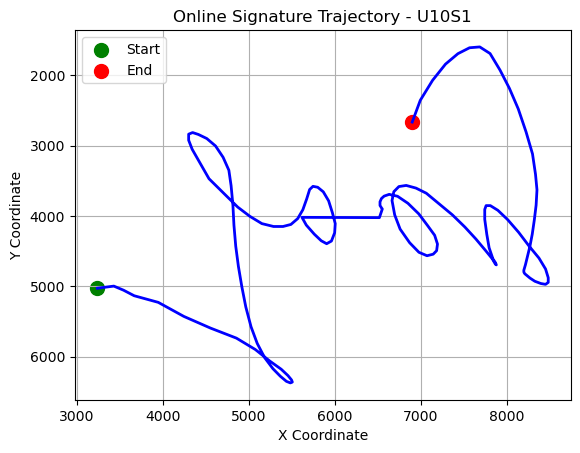

In [16]:
#plt.figure(figsize=(10, 6))

plt.plot(
    signature["x"],signature["y"],color="blue",linewidth=2
)

plt.scatter(
    signature["x"].iloc[0],signature["y"].iloc[0],color="green",s=100,label="Start"
)

plt.scatter(
    signature["x"].iloc[-1],signature["y"].iloc[-1],color="red",s=100,label="End"
)
plt.gca().invert_yaxis()
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.title("Online Signature Trajectory - U10S1")
plt.legend()
plt.grid(True)

plt.show()

## Pressure Visualization

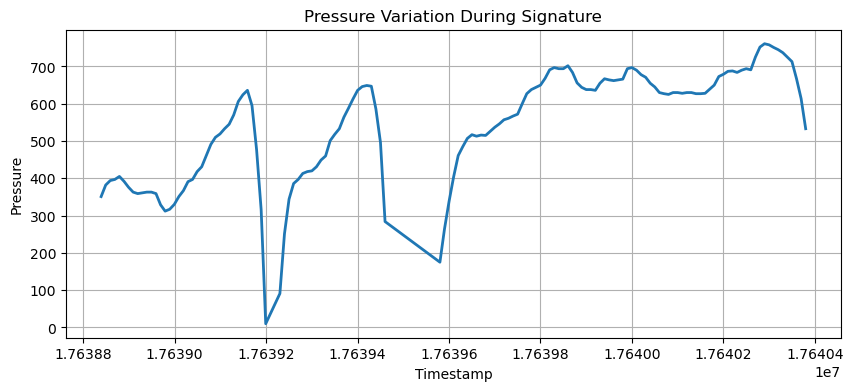

In [21]:
plt.figure(figsize=(10, 4))

plt.plot(
    signature["timestamp"],
    signature["pressure"],
    linewidth=2
)

plt.xlabel("Timestamp")
plt.ylabel("Pressure")
plt.title("Pressure Variation During Signature")

plt.grid(True)
plt.show()

## Pen status Visualization

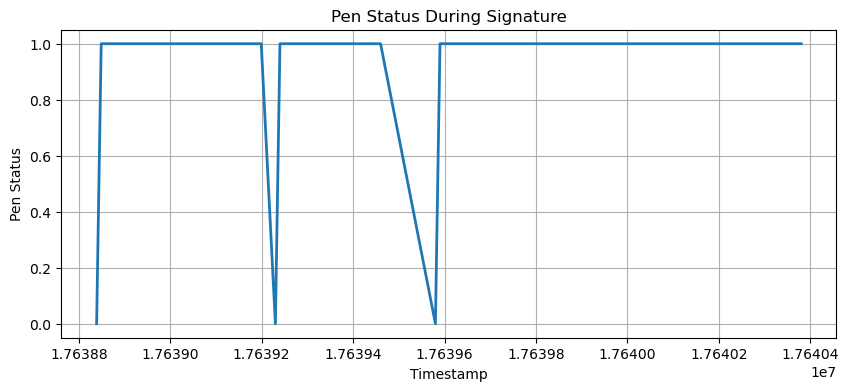

In [22]:
plt.figure(figsize=(10, 4))

plt.plot(
    signature["timestamp"],
    signature["pen_status"],
    linewidth=2
)

plt.xlabel("Timestamp")
plt.ylabel("Pen Status")
plt.title("Pen Status During Signature")

plt.grid(True)
plt.show()

In [23]:
#Step 5a — Signature Duration
duration = signature["timestamp"].iloc[-1] - signature["timestamp"].iloc[0]

print("Signature Duration:", duration)

Signature Duration: 1541


In [24]:
#Step 5b - Feature Ranges
print("Feature Ranges:\n")

for col in signature.columns:
    print(
        f"{col:12} → "
        f"Min: {signature[col].min():.2f}, "
        f"Max: {signature[col].max():.2f}"
    )

Feature Ranges:

x            → Min: 3236.00, Max: 8484.00
y            → Min: 1596.00, Max: 6375.00
timestamp    → Min: 17638839.00, Max: 17640380.00
pen_status   → Min: 0.00, Max: 1.00
azimuth      → Min: 1260.00, Max: 1470.00
altitude     → Min: 370.00, Max: 630.00
pressure     → Min: 10.00, Max: 761.00


In [25]:
#Step 5c
display(signature.describe())

,x,y,timestamp,pen_status,azimuth,altitude,pressure
count,142.000000,142.000000,1.420000e+02,142.000000,142.000000,142.000000,142.000000
mean,6500.690141,4168.239437,1.763962e+07,0.978873,1373.521127,552.746479,544.788732
std,1409.807135,1024.779173,4.661682e+02,0.144316,59.527658,58.831944,146.882103
min,3236.000000,1596.000000,1.763884e+07,0.000000,1260.000000,370.000000,10.000000
25%,5368.500000,3699.250000,1.763919e+07,1.000000,1340.000000,550.000000,418.500000
50%,6692.000000,4130.000000,1.763968e+07,1.000000,1375.000000,570.000000,591.500000
75%,7809.250000,4712.500000,1.764003e+07,1.000000,1420.000000,580.000000,655.750000
max,8484.000000,6375.000000,1.764038e+07,1.000000,1470.000000,630.000000,761.000000


Spatial Information(x, y)-->>CNN(Signature shape & Trajectory)
Sequential Information(x, y, timestamp, pressure, ...)-->>LSTM/RNN

                  ONLINE SIGNATURE
                         │
              ┌──────────┴──────────┐
              ↓                     ↓
        Trajectory/Image       Raw Sequence
              ↓                     ↓
             CNN                 LSTM
              ↓                     ↓
        CNN Features          LSTM Features
              └──────────┬──────────┘
                         ↓
                    Concatenate
                         ↓
                        ANN
                         ↓
                Genuine / Forged

In [17]:
print("Columns:")
print(signature.columns)

print("\nFirst 10 rows:")
display(signature.head(10))

Columns:
Index(['x', 'y', 'timestamp', 'pen_status', 'azimuth', 'altitude', 'pressure'], dtype='object')

First 10 rows:


,x,y,timestamp,pen_status,azimuth,altitude,pressure
0,3236,5028,17638839,0,1260,400,351
1,3428,4998,17638849,1,1260,400,382
2,3541,5056,17638859,1,1260,400,394
3,3665,5135,17638869,1,1310,400,397
4,3945,5229,17638879,1,1370,390,405
5,4243,5429,17638889,1,1420,380,392
6,4553,5595,17638899,1,1470,370,376
7,4855,5738,17638909,1,1460,390,363
8,5075,5900,17638919,1,1450,390,359
9,5240,6061,17638929,1,1440,400,361


In [18]:
print("Data types:")
print(signature.dtypes)

print("\nMissing values:")
print(signature.isnull().sum())

print("\nShape:")
print(signature.shape)

Data types:
x             int64
y             int64
timestamp     int64
pen_status    int64
azimuth       int64
altitude      int64
pressure      int64
dtype: object

Missing values:
x             0
y             0
timestamp     0
pen_status    0
azimuth       0
altitude      0
pressure      0
dtype: int64

Shape:
(142, 7)


In [19]:
display(signature.describe())

,x,y,timestamp,pen_status,azimuth,altitude,pressure
count,142.000000,142.000000,1.420000e+02,142.000000,142.000000,142.000000,142.000000
mean,6500.690141,4168.239437,1.763962e+07,0.978873,1373.521127,552.746479,544.788732
std,1409.807135,1024.779173,4.661682e+02,0.144316,59.527658,58.831944,146.882103
min,3236.000000,1596.000000,1.763884e+07,0.000000,1260.000000,370.000000,10.000000
25%,5368.500000,3699.250000,1.763919e+07,1.000000,1340.000000,550.000000,418.500000
50%,6692.000000,4130.000000,1.763968e+07,1.000000,1375.000000,570.000000,591.500000
75%,7809.250000,4712.500000,1.764003e+07,1.000000,1420.000000,580.000000,655.750000
max,8484.000000,6375.000000,1.764038e+07,1.000000,1470.000000,630.000000,761.000000


In [20]:
for col in signature.columns:
    print(f"\n--- {col} ---")
    print(signature[col].head(10).to_list())


--- x ---
[3236, 3428, 3541, 3665, 3945, 4243, 4553, 4855, 5075, 5240]

--- y ---
[5028, 4998, 5056, 5135, 5229, 5429, 5595, 5738, 5900, 6061]

--- timestamp ---
[17638839, 17638849, 17638859, 17638869, 17638879, 17638889, 17638899, 17638909, 17638919, 17638929]

--- pen_status ---
[0, 1, 1, 1, 1, 1, 1, 1, 1, 1]

--- azimuth ---
[1260, 1260, 1260, 1310, 1370, 1420, 1470, 1460, 1450, 1440]

--- altitude ---
[400, 400, 400, 400, 390, 380, 370, 390, 390, 400]

--- pressure ---
[351, 382, 394, 397, 405, 392, 376, 363, 359, 361]


## 6. What is in datset & also the folder structure

In [27]:
items = os.listdir(dataset_path)

print("Total items:", len(items))
print("\nFirst 20 items:")

for item in items[:20]:
    print(item)

Total items: 1600

First 20 items:
U10S1.TXT
U10S10.TXT
U10S11.TXT
U10S12.TXT
U10S13.TXT
U10S14.TXT
U10S15.TXT
U10S16.TXT
U10S17.TXT
U10S18.TXT
U10S19.TXT
U10S2.TXT
U10S20.TXT
U10S21.TXT
U10S22.TXT
U10S23.TXT
U10S24.TXT
U10S25.TXT
U10S26.TXT
U10S27.TXT


In [28]:
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, "").count(os.sep)
    indent = "    " * level
    
    print(f"{indent}{os.path.basename(root)}/")
    
    for file in files[:5]:
        print(f"{indent}    {file}")
    
    if level >= 2:
        dirs[:] = []

Task2/
    U10S1.TXT
    U10S10.TXT
    U10S11.TXT
    U10S12.TXT
    U10S13.TXT


In [29]:
#Signature Count
txt_files = [
    file for file in os.listdir(dataset_path)
    if file.lower().endswith(".txt")
]

print("Total signature files:", len(txt_files))

Total signature files: 1600


In [30]:
#Filenames
for file in sorted(txt_files):
    print(file)

U10S1.TXT
U10S10.TXT
U10S11.TXT
U10S12.TXT
U10S13.TXT
U10S14.TXT
U10S15.TXT
U10S16.TXT
U10S17.TXT
U10S18.TXT
U10S19.TXT
U10S2.TXT
U10S20.TXT
U10S21.TXT
U10S22.TXT
U10S23.TXT
U10S24.TXT
U10S25.TXT
U10S26.TXT
U10S27.TXT
U10S28.TXT
U10S29.TXT
U10S3.TXT
U10S30.TXT
U10S31.TXT
U10S32.TXT
U10S33.TXT
U10S34.TXT
U10S35.TXT
U10S36.TXT
U10S37.TXT
U10S38.TXT
U10S39.TXT
U10S4.TXT
U10S40.TXT
U10S5.TXT
U10S6.TXT
U10S7.TXT
U10S8.TXT
U10S9.TXT
U11S1.TXT
U11S10.TXT
U11S11.TXT
U11S12.TXT
U11S13.TXT
U11S14.TXT
U11S15.TXT
U11S16.TXT
U11S17.TXT
U11S18.TXT
U11S19.TXT
U11S2.TXT
U11S20.TXT
U11S21.TXT
U11S22.TXT
U11S23.TXT
U11S24.TXT
U11S25.TXT
U11S26.TXT
U11S27.TXT
U11S28.TXT
U11S29.TXT
U11S3.TXT
U11S30.TXT
U11S31.TXT
U11S32.TXT
U11S33.TXT
U11S34.TXT
U11S35.TXT
U11S36.TXT
U11S37.TXT
U11S38.TXT
U11S39.TXT
U11S4.TXT
U11S40.TXT
U11S5.TXT
U11S6.TXT
U11S7.TXT
U11S8.TXT
U11S9.TXT
U12S1.TXT
U12S10.TXT
U12S11.TXT
U12S12.TXT
U12S13.TXT
U12S14.TXT
U12S15.TXT
U12S16.TXT
U12S17.TXT
U12S18.TXT
U12S19.TXT
U12S2.TXT
U12S20.T

In [31]:
#Identify users
import re

users = sorted(set(
    re.match(r"(U\d+)", file.upper()).group(1)
    for file in txt_files
    if re.match(r"(U\d+)", file.upper())
))

print("Number of users:", len(users))
print("Users:", users)

Number of users: 40
Users: ['U1', 'U10', 'U11', 'U12', 'U13', 'U14', 'U15', 'U16', 'U17', 'U18', 'U19', 'U2', 'U20', 'U21', 'U22', 'U23', 'U24', 'U25', 'U26', 'U27', 'U28', 'U29', 'U3', 'U30', 'U31', 'U32', 'U33', 'U34', 'U35', 'U36', 'U37', 'U38', 'U39', 'U4', 'U40', 'U5', 'U6', 'U7', 'U8', 'U9']


In [32]:
#Count signature of each user
from collections import Counter

user_counts = Counter(
    re.match(r"(U\d+)", file.upper()).group(1)
    for file in txt_files
    if re.match(r"(U\d+)", file.upper())
)

for user, count in sorted(user_counts.items()):
    print(f"{user}: {count} signatures")

U1: 40 signatures
U10: 40 signatures
U11: 40 signatures
U12: 40 signatures
U13: 40 signatures
U14: 40 signatures
U15: 40 signatures
U16: 40 signatures
U17: 40 signatures
U18: 40 signatures
U19: 40 signatures
U2: 40 signatures
U20: 40 signatures
U21: 40 signatures
U22: 40 signatures
U23: 40 signatures
U24: 40 signatures
U25: 40 signatures
U26: 40 signatures
U27: 40 signatures
U28: 40 signatures
U29: 40 signatures
U3: 40 signatures
U30: 40 signatures
U31: 40 signatures
U32: 40 signatures
U33: 40 signatures
U34: 40 signatures
U35: 40 signatures
U36: 40 signatures
U37: 40 signatures
U38: 40 signatures
U39: 40 signatures
U4: 40 signatures
U40: 40 signatures
U5: 40 signatures
U6: 40 signatures
U7: 40 signatures
U8: 40 signatures
U9: 40 signatures


## Understanding for now

In [36]:
#Fix the loader
sample_file = os.path.join(dataset_path, "U10S1.TXT")

with open(sample_file, "r") as f:
    for i in range(10):
        line = f.readline()
        print(repr(line))

'142\n'
'3236 5028 17638839 0 1260 400 351\n'
'3428 4998 17638849 1 1260 400 382\n'
'3541 5056 17638859 1 1260 400 394\n'
'3665 5135 17638869 1 1310 400 397\n'
'3945 5229 17638879 1 1370 390 405\n'
'4243 5429 17638889 1 1420 380 392\n'
'4553 5595 17638899 1 1470 370 376\n'
'4855 5738 17638909 1 1460 390 363\n'
'5075 5900 17638919 1 1450 390 359\n'


In [37]:
with open(sample_file, "r") as f:
    lines = f.readlines()

print("Total lines:", len(lines))

print("\nFirst 5 lines:")
for line in lines[:5]:
    print(line)

Total lines: 143

First 5 lines:
142

3236 5028 17638839 0 1260 400 351

3428 4998 17638849 1 1260 400 382

3541 5056 17638859 1 1260 400 394

3665 5135 17638869 1 1310 400 397



## 7. Check whether all files have the same structure

In [38]:
sample_file = os.path.join(dataset_path, "U10S1.TXT")

with open(sample_file, "r") as f:
    lines = f.readlines()

# First line contains number of points
num_points = int(lines[0].strip())

# Remaining lines contain the 7 features
signature = pd.DataFrame(
    [line.strip().split() for line in lines[1:] if line.strip()],
    columns=["x","y","timestamp","pen_status","azimuth","altitude","pressure"
    ]
)

# Convert all columns to numeric
signature = signature.astype(float)

print("Expected points:", num_points)
print("Actual points:", len(signature))
print("Shape:", signature.shape)

display(signature.head())

Expected points: 142
Actual points: 142
Shape: (142, 7)


,x,y,timestamp,pen_status,azimuth,altitude,pressure
0,3236.0,5028.0,17638839.0,0.0,1260.0,400.0,351.0
1,3428.0,4998.0,17638849.0,1.0,1260.0,400.0,382.0
2,3541.0,5056.0,17638859.0,1.0,1260.0,400.0,394.0
3,3665.0,5135.0,17638869.0,1.0,1310.0,400.0,397.0
4,3945.0,5229.0,17638879.0,1.0,1370.0,390.0,405.0


## 8. Now load ALL 1600 signatures

all_signatures = {}

for file in txt_files:
    file_path = os.path.join(dataset_path, file)

    with open(file_path, "r") as f:
        lines = f.readlines()

    num_points = int(lines[0].strip())

    df = pd.DataFrame(
        [line.strip().split() for line in lines[1:] if line.strip()],
        columns=[
            "x","y","timestamp","pen_status","azimuth","altitude","pressure"]
    )
    df = df.astype(float)
    all_signatures[file] = df

print("Total signatures loaded:", len(all_signatures))

## 9. Verify everything

In [40]:
print("U10S1 shape:", all_signatures["U10S1.TXT"].shape)
print("\nU10S10 shape:", all_signatures["U10S10.TXT"].shape)
print("\nU1S1 shape:", all_signatures.get("U1S1.TXT", "File not found"))

U10S1 shape: (142, 7)

U10S10 shape: (145, 7)

U1S1 shape:          x       y   timestamp  pen_status  azimuth  altitude  pressure
0   2933.0  5678.0  31275775.0         0.0   1550.0     710.0     439.0
1   2933.0  5678.0  31275785.0         1.0   1480.0     770.0     420.0
2   3001.0  5851.0  31275795.0         1.0   1350.0     830.0     433.0
3   3114.0  6139.0  31275805.0         1.0   1350.0     800.0     422.0
4   3217.0  6198.0  31275815.0         1.0   1350.0     800.0     415.0
..     ...     ...         ...         ...      ...       ...       ...
79  8266.0  5308.0  31276876.0         1.0   1430.0     530.0     561.0
80  7398.0  5917.0  31276957.0         0.0   1480.0     530.0     822.0
81  7093.0  5611.0  31276967.0         1.0   1490.0     530.0     748.0
82  6941.0  5499.0  31276977.0         1.0   1500.0     520.0     749.0
83  6862.0  5477.0  31276987.0         1.0   1510.0     510.0     636.0

[84 rows x 7 columns]


In [41]:
shape_summary = pd.DataFrame({
    "file": all_signatures.keys(),
    "timesteps": [df.shape[0] for df in all_signatures.values()],
    "features": [df.shape[1] for df in all_signatures.values()]
})

display(shape_summary.head(10))

print("Total files:", len(shape_summary))
print("Unique feature counts:", shape_summary["features"].unique())

,file,timesteps,features
0,U10S1.TXT,142,7
1,U10S10.TXT,145,7
2,U10S11.TXT,147,7
3,U10S12.TXT,140,7
4,U10S13.TXT,153,7
5,U10S14.TXT,156,7
6,U10S15.TXT,155,7
7,U10S16.TXT,142,7
8,U10S17.TXT,160,7
9,U10S18.TXT,133,7


Total files: 1600
Unique feature counts: [7]


## 10. Inspect the signature numbering

In [42]:
for user in ["U1", "U2", "U10", "U20"]:
    user_files = [
        file for file in txt_files
        if file.upper().startswith(user.upper() + "S")
    ]
    
    print(f"\n{user}:")
    print(sorted(user_files))


U1:
['U1S1.TXT', 'U1S10.TXT', 'U1S11.TXT', 'U1S12.TXT', 'U1S13.TXT', 'U1S14.TXT', 'U1S15.TXT', 'U1S16.TXT', 'U1S17.TXT', 'U1S18.TXT', 'U1S19.TXT', 'U1S2.TXT', 'U1S20.TXT', 'U1S21.TXT', 'U1S22.TXT', 'U1S23.TXT', 'U1S24.TXT', 'U1S25.TXT', 'U1S26.TXT', 'U1S27.TXT', 'U1S28.TXT', 'U1S29.TXT', 'U1S3.TXT', 'U1S30.TXT', 'U1S31.TXT', 'U1S32.TXT', 'U1S33.TXT', 'U1S34.TXT', 'U1S35.TXT', 'U1S36.TXT', 'U1S37.TXT', 'U1S38.TXT', 'U1S39.TXT', 'U1S4.TXT', 'U1S40.TXT', 'U1S5.TXT', 'U1S6.TXT', 'U1S7.TXT', 'U1S8.TXT', 'U1S9.TXT']

U2:
['U2S1.TXT', 'U2S10.TXT', 'U2S11.TXT', 'U2S12.TXT', 'U2S13.TXT', 'U2S14.TXT', 'U2S15.TXT', 'U2S16.TXT', 'U2S17.TXT', 'U2S18.TXT', 'U2S19.TXT', 'U2S2.TXT', 'U2S20.TXT', 'U2S21.TXT', 'U2S22.TXT', 'U2S23.TXT', 'U2S24.TXT', 'U2S25.TXT', 'U2S26.TXT', 'U2S27.TXT', 'U2S28.TXT', 'U2S29.TXT', 'U2S3.TXT', 'U2S30.TXT', 'U2S31.TXT', 'U2S32.TXT', 'U2S33.TXT', 'U2S34.TXT', 'U2S35.TXT', 'U2S36.TXT', 'U2S37.TXT', 'U2S38.TXT', 'U2S39.TXT', 'U2S4.TXT', 'U2S40.TXT', 'U2S5.TXT', 'U2S6.TXT', 'U

## 11. Check the actual file sizes/timesteps

display(shape_summary.sort_values("timesteps").head(10)
)

display(shape_summary.sort_values("timesteps", ascending=False).head(10)
)

## 12. Create labels

In [45]:
import re
import pandas as pd
metadata = []
for file in txt_files:
    match = re.match(r"U(\d+)S(\d+)", file.upper())
    
    if match:
        user_id = int(match.group(1))
        signature_id = int(match.group(2))
        
        if signature_id <= 20:
            label = 0
            label_name = "Genuine"
        else:
            label = 1
            label_name = "Forged"
        
        metadata.append({
            "file": file,"user_id": user_id,"signature_id": signature_id,"label": label,"label_name": label_name
        })

metadata_df = pd.DataFrame(metadata)

display(metadata_df.head(10))

,file,user_id,signature_id,label,label_name
0,U10S1.TXT,10,1,0,Genuine
1,U10S10.TXT,10,10,0,Genuine
2,U10S11.TXT,10,11,0,Genuine
3,U10S12.TXT,10,12,0,Genuine
4,U10S13.TXT,10,13,0,Genuine
5,U10S14.TXT,10,14,0,Genuine
6,U10S15.TXT,10,15,0,Genuine
7,U10S16.TXT,10,16,0,Genuine
8,U10S17.TXT,10,17,0,Genuine
9,U10S18.TXT,10,18,0,Genuine


## 12. Verify our labels

In [46]:
print("Total signatures:", len(metadata_df))

print("\nLabel distribution:")
print(metadata_df["label_name"].value_counts())

Total signatures: 1600

Label distribution:
label_name
Genuine    800
Forged     800
Name: count, dtype: int64


In [47]:
display(
    pd.crosstab(
        metadata_df["user_id"],metadata_df["label_name"]
))

label_name,Forged,Genuine
user_id,,
1,20,20
2,20,20
3,20,20
4,20,20
5,20,20
6,20,20
7,20,20
8,20,20
9,20,20


## 13. Genuine vs Forged Signature Distribution

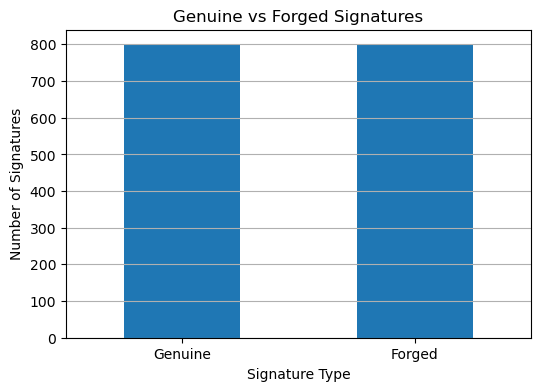

In [49]:
plt.figure(figsize=(6, 4))

metadata_df["label_name"].value_counts().plot(kind="bar")

plt.xlabel("Signature Type")
plt.ylabel("Number of Signatures")
plt.title("Genuine vs Forged Signatures")

plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

## 14. Signature Sequence Length Analysis

Each signature contains a different number of time points.
We analyze the distribution of sequence lengths before preparing
the data for the LSTM model.

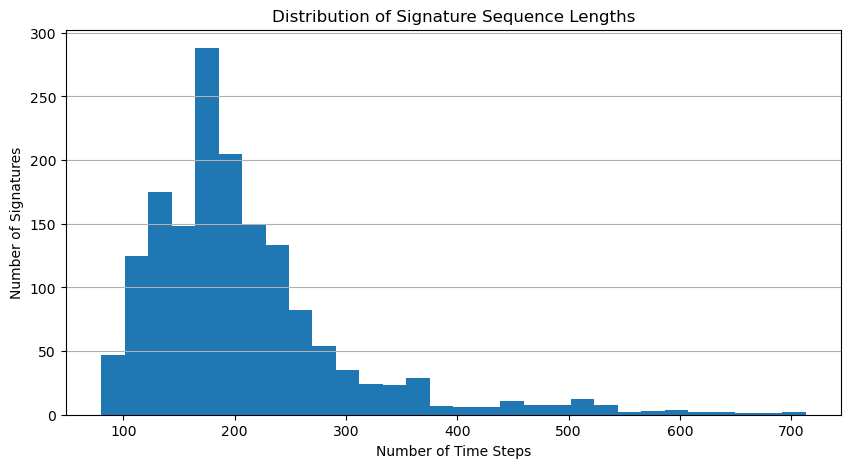

In [50]:
plt.figure(figsize=(10, 5))

plt.hist(
    shape_summary["timesteps"],
    bins=30
)

plt.xlabel("Number of Time Steps")
plt.ylabel("Number of Signatures")
plt.title("Distribution of Signature Sequence Lengths")

plt.grid(axis="y")

plt.show()

## 15. Get exact sequence statistics

In [51]:
shape_summary["timesteps"].describe()

count    1600.000000
mean      208.208125
std        91.319696
min        80.000000
25%       152.000000
50%       187.000000
75%       236.000000
max       713.000000
Name: timesteps, dtype: float64

## 16. Compare Genuine vs Forged sequence lengths

In [52]:
length_analysis = shape_summary.merge(
    metadata_df[["file", "label_name"]],
    on="file"
)

display(
    length_analysis.groupby("label_name")["timesteps"].describe()
)

,count,mean,std,min,25%,50%,75%,max
label_name,,,,,,,,
Forged,800.0,232.09250,98.713458,85.0,173.75,210.0,255.0,713.0
Genuine,800.0,184.32375,76.172891,80.0,133.00,172.0,205.0,563.0


## 17. Visualization of Genuine vs Forged sequence length

<Figure size 800x500 with 0 Axes>

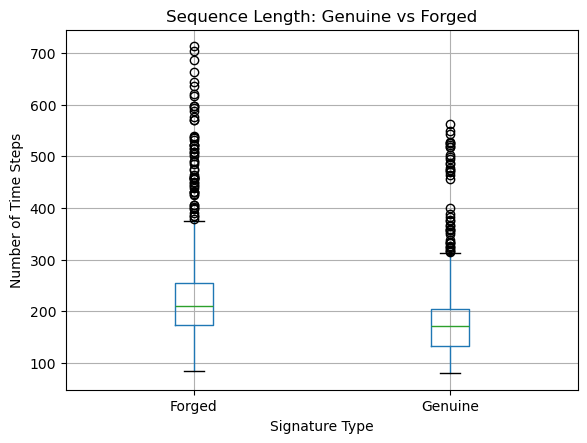

In [55]:
plt.figure(figsize=(8, 5))

length_analysis.boxplot(
    column="timesteps",
    by="label_name"
)

plt.xlabel("Signature Type")
plt.ylabel("Number of Time Steps")
plt.title("Sequence Length: Genuine vs Forged")

plt.suptitle("")

plt.show()

## 18. Check data quality

In [56]:
quality_results = []

for file, df in all_signatures.items():
    quality_results.append({
        "file": file,
        "missing_values": df.isnull().sum().sum(),
        "infinite_values": np.isinf(df.select_dtypes(include=np.number)).sum().sum(),
        "timesteps": len(df)
    })

quality_df = pd.DataFrame(quality_results)

display(quality_df.head())

,file,missing_values,infinite_values,timesteps
0,U10S1.TXT,0,0,142
1,U10S10.TXT,0,0,145
2,U10S11.TXT,0,0,147
3,U10S12.TXT,0,0,140
4,U10S13.TXT,0,0,153


In [57]:
print("Total missing values:",
      quality_df["missing_values"].sum())

print("Total infinite values:",
      quality_df["infinite_values"].sum())

Total missing values: 0
Total infinite values: 0


## 19. Final dataset summary

In [58]:
print("========== DATASET SUMMARY ==========")

print("Total users:", metadata_df["user_id"].nunique())
print("Total signatures:", len(metadata_df))
print("Genuine signatures:", (metadata_df["label"] == 0).sum())
print("Forged signatures:", (metadata_df["label"] == 1).sum())
print("Features per signature:", 7)

print("\nSequence length:")
print("Minimum:", shape_summary["timesteps"].min())
print("Maximum:", shape_summary["timesteps"].max())
print("Mean:", round(shape_summary["timesteps"].mean(), 2))
print("Median:", shape_summary["timesteps"].median())

========== DATASET SUMMARY ==========
Total users: 40
Total signatures: 1600
Genuine signatures: 800
Forged signatures: 800
Features per signature: 7

Sequence length:
Minimum: 80
Maximum: 713
Mean: 208.21
Median: 187.0
